## Simple classification task: separate bottom players from top players

I've been using a lot of LLM-generated code recently. Let's take a step back
and try to understand what each step of the program does in a basic task.
It will help us to progress in a useful direction later.

In [1]:
from pathlib import Path
import urllib.request

# Configuration
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

# File info (month and year)
year = 2017
month = 5

# Make file path
filename = f"lichess_db_standard_rated_{year}-{month:02d}.pgn.zst"
zst_path = RAW_DIR / filename

# Download PGN file
if not zst_path.exists():
  print(f"Downloading {filename}...")

  url = f"https://database.lichess.org/standard/{filename}"
  urllib.request.urlretrieve(url, zst_path)
  print("Done.")
else:
  print("File already exists.")


File already exists.


## Parse a small PGN subset

In [2]:
import io
import chess
import pandas as pd
import numpy as np
import zstandard as zstd    # reading .zst files
from tqdm.auto import tqdm  # progress bar


# Parameters
MAX_GAMES_TO_READ = 50_000


# Helper functions
def iter_pgn_games_from_zst(zst_path, max_games=None):
  """Yield python-chess Game objects from a compressed Lichess PGN file."""
  dctx = zstd.ZstdDecompressor()

  with open(zst_path, "rb") as compressed:
    with dctx.stream_reader(compressed) as reader:
      text_stream = io.TextIOWrapper(reader, encoding="utf-8")

      n_games = 0
      while True:
        game = chess.pgn.read_game(text_stream)

        if game is None:
          break

        yield game
        n_games += 1

        if max_games is not None and n_games >= max_games:
          break


def parse_rating(value):
  """Parse Lichess rating headers, keeping provisional '?' information separate."""
  if value is None:
    return np.nan, False

  text = str(value).strip()
  is_provisional = text.endswith("?")
  text = text.replace("?", "")

  try:
    return float(text), is_provisional
  except ValueError:
    return np.nan, is_provisional


def game_to_light_record(game):
  """Extract metadata plus SAN/UCI moves without doing engine analysis yet."""
  headers = game.headers
  board = game.board()

  moves_san = []
  moves_uci = []

  for move in game.mainline_moves():
    moves_san.append(board.san(move))
    moves_uci.append(move.uci())
    board.push(move)

  white_elo, white_provisional = parse_rating(headers.get("WhiteElo"))
  black_elo, black_provisional = parse_rating(headers.get("BlackElo"))

  return {
    "event": headers.get("Event"),
    "site": headers.get("Site"),
    "date": headers.get("UTCDate", headers.get("Date")),
    "time": headers.get("UTCTime"),
    "white": headers.get("White"),
    "black": headers.get("Black"),
    "result": headers.get("Result"),
    "white_elo": white_elo,
    "black_elo": black_elo,
    "white_provisional": white_provisional,
    "black_provisional": black_provisional,
    "white_rating_diff": headers.get("WhiteRatingDiff"),
    "black_rating_diff": headers.get("BlackRatingDiff"),
    "eco": headers.get("ECO"),
    "opening": headers.get("Opening"),
    "time_control": headers.get("TimeControl"),
    "termination": headers.get("Termination"),
    "num_plies": len(moves_uci),
    "num_full_moves": len(moves_uci) / 2,
    "moves_san": " ".join(moves_san),
    "moves_uci": " ".join(moves_uci),
  }


metadata_path = PROCESSED_DIR / (
  f"lichess_{year}_{month:02d}_metadata_first_{MAX_GAMES_TO_READ}.parquet"
)


if metadata_path.exists():
  df_raw = pd.read_parquet(metadata_path)
  print(f"Loaded cached metadata: {metadata_path}")
else:
  records = []
  game_iter = iter_pgn_games_from_zst(
    zst_path,
    max_games=MAX_GAMES_TO_READ
  )

  for game in tqdm(game_iter, total=MAX_GAMES_TO_READ):
    records.append(game_to_light_record(game))

  df_raw = pd.DataFrame(records)
  df_raw.to_parquet(metadata_path, index=False)
  print(f"Wrote: {metadata_path}")

df_raw.head()

Loaded cached metadata: data/processed/lichess_2017_05_metadata_first_50000.parquet


,event,site,date,time,white,black,result,white_elo,black_elo,white_provisional,...,white_rating_diff,black_rating_diff,eco,opening,time_control,termination,num_plies,num_full_moves,moves_san,moves_uci
0,Rated Bullet game,https://lichess.org/ObT3MGJ6,2017.04.30,22:00:00,marshall91,Nechemevich,0-1,1926.0,1969.0,False,...,-10,+9,B01,Scandinavian Defense: Modern Variation #2,60+0,Time forfeit,92,46.0,e4 d5 exd5 Nf6 d3 Qxd5 Nc3 Qf5 Be2 Bd7 g4 Qe6 ...,e2e4 d7d5 e4d5 g8f6 d2d3 d8d5 b1c3 d5f5 f1e2 c...
1,Rated Bullet game,https://lichess.org/wcL9cyTi,2017.04.30,22:00:00,LTKAUNAS,Paupara,1-0,1592.0,1427.0,False,...,+6,-6,A00,Mieses Opening,60+0,Time forfeit,79,39.5,d3 e6 e3 d5 Nf3 Nf6 Be2 Be7 O-O O-O Nc3 Nbd7 N...,d2d3 e7e6 e2e3 d7d5 g1f3 g8f6 f1e2 f8e7 e1g1 e...
2,Rated Bullet game,https://lichess.org/D32us0RF,2017.04.30,22:00:00,ateoluz,yigitmustafa,1-0,1247.0,1174.0,False,...,+9,-9,D00,Blackmar-Diemer Gambit,60+0,Time forfeit,45,22.5,d4 d5 e4 dxe4 c4 Nf6 Qc2 Bf5 Nc3 Qxd4 Be3 Qe5 ...,d2d4 d7d5 e2e4 d5e4 c2c4 g8f6 d1c2 c8f5 b1c3 d...
3,Rated Bullet game,https://lichess.org/6RBz5epC,2017.04.30,22:00:00,le_batman,aleksandra_91,1-0,2047.0,2009.0,False,...,+8,-9,A00,Van't Kruijs Opening,60+0,Time forfeit,95,47.5,e3 c5 d3 d5 Nf3 Nc6 Be2 Nf6 O-O g6 h3 Bg7 Re1 ...,e2e3 c7c5 d2d3 d7d5 g1f3 b8c6 f1e2 g8f6 e1g1 g...
4,Rated Blitz game,https://lichess.org/z2b2Y95l,2017.04.30,22:00:00,Trollson,salahi2,1-0,1767.0,1781.0,False,...,+10,-11,B01,Scandinavian Defense: Mieses-Kotroc Variation,300+0,Time forfeit,75,37.5,e4 d5 exd5 Qxd5 Nc3 Qd8 d4 Bf5 Nf3 e6 Nh4 Bg6 ...,e2e4 d7d5 e4d5 d8d5 b1c3 d5d8 d2d4 c8f5 g1f3 e...


## Data exploration (basic)

In [3]:
print(df_raw.shape)
df_raw.info()

(50000, 21)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   event              50000 non-null  str    
 1   site               50000 non-null  str    
 2   date               50000 non-null  str    
 3   time               50000 non-null  str    
 4   white              50000 non-null  str    
 5   black              50000 non-null  str    
 6   result             50000 non-null  str    
 7   white_elo          50000 non-null  float64
 8   black_elo          50000 non-null  float64
 9   white_provisional  50000 non-null  bool   
 10  black_provisional  50000 non-null  bool   
 11  white_rating_diff  49977 non-null  str    
 12  black_rating_diff  49977 non-null  str    
 13  eco                50000 non-null  str    
 14  opening            50000 non-null  str    
 15  time_control       50000 non-null  str    
 16  termination        50

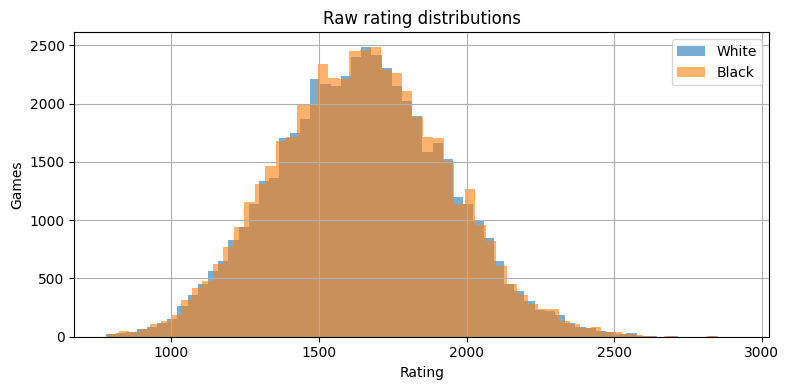

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
df_raw["white_elo"].hist(bins=60, alpha=0.6, ax=ax, label="White")
df_raw["black_elo"].hist(bins=60, alpha=0.6, ax=ax, label="Black")
ax.set_xlabel("Rating")
ax.set_ylabel("Games")
ax.set_title("Raw rating distributions")
ax.legend()
plt.tight_layout()
plt.show()

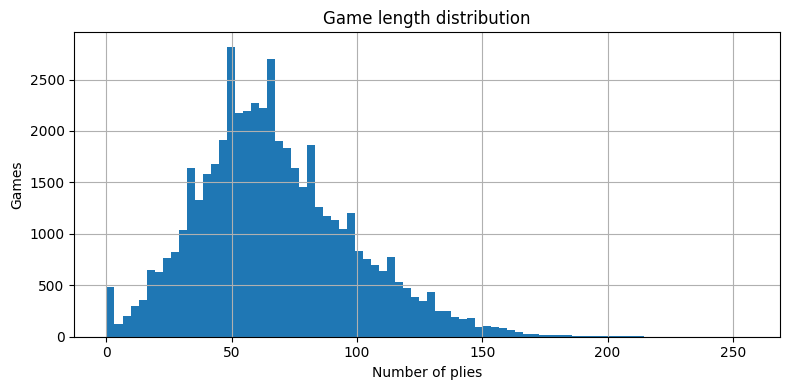

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
df_raw["num_plies"].hist(bins=80, ax=ax)
ax.set_xlabel("Number of plies")
ax.set_ylabel("Games")
ax.set_title("Game length distribution")
plt.tight_layout()
plt.show()

In [6]:
print("Results:")
display(df_raw["result"].value_counts(dropna=False).to_frame("count"))

print("\nTermination:")
display(df_raw["termination"].value_counts(dropna=False).head(20).to_frame("count"))

print("\nTime controls:")
display(df_raw["time_control"].value_counts(dropna=False).head(20).to_frame("count"))

print("\nOpenings:")
display(df_raw["opening"].value_counts(dropna=False).head(20).to_frame("count"))

print("\nTime:")
display(df_raw["time"].value_counts(dropna=False).head(20).to_frame("count"))

print("\nEvents:")
display(df_raw["event"].value_counts(dropna=False).head(20).to_frame("count"))

Results:


,count
result,
1-0,24765
0-1,23331
1/2-1/2,1896
*,8



Termination:


,count
termination,
Normal,32906
Time forfeit,16849
Abandoned,234
Unterminated,6
Rules infraction,5



Time controls:


...

,count
opening,
Van't Kruijs Opening,958
Scandinavian Defense: Mieses-Kotroc Variation,910
Modern Defense,774
Sicilian Defense,685
Scandinavian Defense,673
Horwitz Defense,652
French Defense: Knight Variation,650
Owen Defense,613
Caro-Kann Defense,608



Time:


,count
time,
22:00:01,84
00:00:02,66
23:00:03,56
01:00:02,44
22:27:07,33
22:36:38,29
22:55:44,29
22:24:52,26
22:55:30,26



Events:


,count
event,
Rated Blitz game,19505
Rated Classical game,10704
Rated Bullet game,10650
Rated Classical tournament https://lichess.org/tournament/Ajk1flnF,535
Rated UltraBullet game,496
Rated Blitz tournament https://lichess.org/tournament/3xxzNmSV,474
Rated Bullet tournament https://lichess.org/tournament/QrSb3mjZ,463
Rated Blitz tournament https://lichess.org/tournament/lMB6mMlI,421
Rated Blitz tournament https://lichess.org/tournament/ty447zFJ,417


## Filter data

In [7]:
# Data filters. Self explanatory
MIN_PLIES = 20
REMOVE_PROVISIONAL = True
BLITZ_ONLY = True       # Do only the most popular category to begin,
                        # perhaps people play differently in diff. categories?

valid_mask = (
  df_raw["white_elo"].notna()
  & df_raw["black_elo"].notna()
  & df_raw["result"].isin(["1-0", "0-1", "1/2-1/2"])
  & df_raw["moves_uci"].notna()
  & df_raw["num_plies"].ge(MIN_PLIES)
)

if REMOVE_PROVISIONAL:
  valid_mask &= ~(
    df_raw["white_provisional"].fillna(False)
    | df_raw["black_provisional"].fillna(False)
  )

if BLITZ_ONLY:
  valid_mask &= (
    df_raw["event"].eq("Rated Blitz game")
  )

# Check
df_games = df_raw.loc[valid_mask].copy()

print("Rows before filtering:", len(df_raw))
print("Rows after filtering: ", len(df_games))
print("Removed:              ", len(df_raw) - len(df_games))

df_games[["white_elo", "black_elo", "num_plies"]].describe()


Rows before filtering: 50000
Rows after filtering:  18855
Removed:               31145


,white_elo,black_elo,num_plies
count,18855.000000,18855.000000,18855.000000
mean,1634.362079,1633.201485,71.149722
std,288.171204,288.704094,30.596650
min,778.000000,789.000000,20.000000
25%,1434.000000,1432.000000,49.000000
50%,1639.000000,1638.000000,66.000000
75%,1833.000000,1833.000000,90.000000
max,2594.000000,2591.000000,254.000000


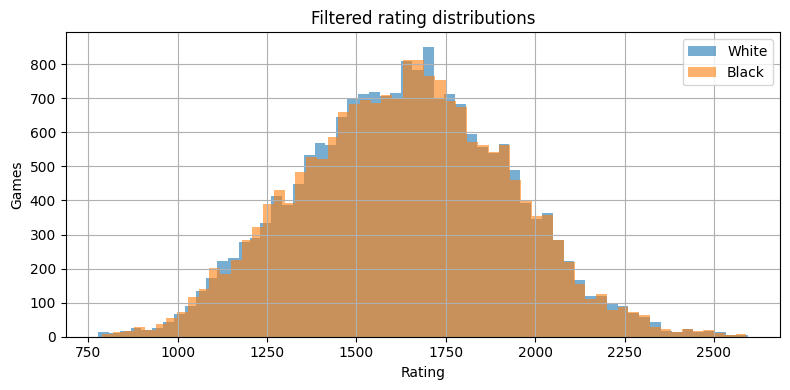

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
df_games["white_elo"].hist(bins=60, alpha=0.6, ax=ax, label="White")
df_games["black_elo"].hist(bins=60, alpha=0.6, ax=ax, label="Black")
ax.set_xlabel("Rating")
ax.set_ylabel("Games")
ax.set_title("Filtered rating distributions")
ax.legend()
plt.tight_layout()
plt.show()

## Build low/high player classes

In [9]:
df_class = df_games.copy()

df_class["avg_elo"] = (
  df_class["white_elo"] + df_class["black_elo"]
) / 2

df_class["elo_diff_abs"] = (
  df_class["white_elo"] - df_class["black_elo"]
).abs()

# Classification setup
LOW_MAX_ELO = 1200
HIGH_MIN_ELO = 2100

# Use both players' ratings to define a clean game-level label.
# This avoids games like 900 vs 2200, where one side is strong and one is weak.
REQUIRE_BOTH_PLAYERS_IN_BAND = True

if REQUIRE_BOTH_PLAYERS_IN_BAND:
  low_mask = (
    df_class["white_elo"].lt(LOW_MAX_ELO)
    & df_class["black_elo"].lt(LOW_MAX_ELO)
  )

  high_mask = (
    df_class["white_elo"].gt(HIGH_MIN_ELO)
    & df_class["black_elo"].gt(HIGH_MIN_ELO)
  )
else:
  low_mask = df_class["avg_elo"].lt(LOW_MAX_ELO)
  high_mask = df_class["avg_elo"].gt(HIGH_MIN_ELO)

df_low = df_class.loc[low_mask].copy()
df_high = df_class.loc[high_mask].copy()

df_low["rating_class"] = 0
df_low["rating_class_name"] = "low"

df_high["rating_class"] = 1
df_high["rating_class_name"] = "high"

print("Low-rated candidate games: ", len(df_low))
print("High-rated candidate games:", len(df_high))

Low-rated candidate games:  846
High-rated candidate games: 604


In [10]:
# Engine settings
N_GAMES_ENGINE_TOTAL = 1000
RANDOM_STATE = 24

# Balance the two classes before engine analysis.
# This prevents the classifier from learning class imbalance.
n_per_class = min(
  len(df_low),
  len(df_high),
  N_GAMES_ENGINE_TOTAL // 2,
)

if n_per_class == 0:
  raise ValueError(
    "No games found in at least one class. "
    "Try increasing MAX_GAMES_TO_READ or relaxing the rating cuts."
  )

df_low_sample = df_low.sample(
  n=n_per_class,
  random_state=RANDOM_STATE,
)

df_high_sample = df_high.sample(
  n=n_per_class,
  random_state=RANDOM_STATE,
)

# Build bivariate sample
df_bvt = pd.concat(
  [df_low_sample, df_high_sample],
  axis=0,
).sample(
  frac=1,
  random_state=RANDOM_STATE,
).reset_index(drop=True)

df_bvt["game_id"] = np.arange(len(df_bvt))

# Check
print(df_bvt["rating_class_name"].value_counts())
display(
  df_bvt[
    [
      "rating_class_name",
      "white_elo",
      "black_elo",
      "avg_elo",
      "elo_diff_abs",
      "num_plies",
      "result",
      "eco",
      "opening",
      "time_control",
    ]
  ].groupby("rating_class_name").describe()
)

rating_class_name
low     500
high    500
Name: count, dtype: int64


white_elo                                                 \
                      count      mean         std     min      25%     50%   
rating_class_name                                                            
high                  500.0  2257.616  114.089392  2101.0  2172.75  2238.0   
low                   500.0  1084.600   86.882779   778.0  1046.00  1100.0   

                                  black_elo            ... elo_diff_abs  \
                      75%     max     count      mean  ...          75%   
rating_class_name                                      ...                
high               2309.0  2594.0     500.0  2258.404  ...       116.00   
low                1150.0  1199.0     500.0  1078.878  ...       114.25   

                         num_plies                                       \
                     max     count    mean        std   min   25%   50%   
rating_class_name                                                         
high               462.0     500.0  82.108  34.400918  20.0  55.0  78.0   
low                381.0     500.0  60.566  27.177028  20.0  40.0  56.0   

                                  
                      75%    max  
rating_class_name                 
high               105.25  254.0  
low                 76.00  162.0  

[2 rows x 40 columns]

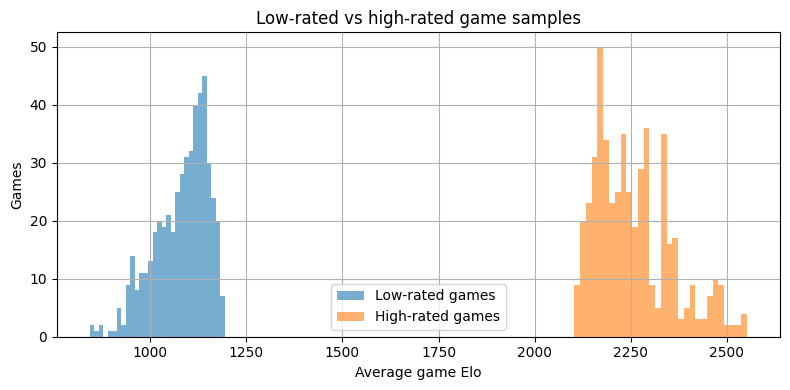

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

df_bvt.loc[df_bvt["rating_class"].eq(0), "avg_elo"].hist(
  bins=30,
  alpha=0.6,
  ax=ax,
  label="Low-rated games",
)

df_bvt.loc[df_bvt["rating_class"].eq(1), "avg_elo"].hist(
  bins=30,
  alpha=0.6,
  ax=ax,
  label="High-rated games",
)

ax.set_xlabel("Average game Elo")
ax.set_ylabel("Games")
ax.set_title("Low-rated vs high-rated game samples")
ax.legend()
plt.tight_layout()
plt.show()

## Run stockfish analysis

In [12]:
import os
import shutil
import ast
import chess.engine


# Settings
STOCKFISH_PATH = os.environ.get("STOCKFISH_PATH") or shutil.which("stockfish")
ENGINE_DEPTH = 12     # number of future plies that stockfish checks each move;)
ENGINE_THREADS = 8
ENGINE_HASH_MB = 512
MATE_SCORE = 100_000  # cap extreme mate conversion score
CP_LOSS_CLIP = 2_000  # ^
INACCURACY_CP = 50    # move quality threshold in centipawns
MISTAKE_CP = 100      # ^
BLUNDER_CP = 300      # ^^


# Helper functions
def coerce_moves_uci(value):
  """Return a Python list of UCI moves from several possible storage formats."""
  if isinstance(value, list):
    return value

  if isinstance(value, tuple):
    return list(value)

  if value is None:
    return []

  if isinstance(value, float) and np.isnan(value):
    return []

  if isinstance(value, str):
    text = value.strip()

    if text.startswith("[") and text.endswith("]"):
      try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
          return parsed
      except Exception:
        pass

    # Fallback for space-separated UCI strings.
    return text.split()

  return []


def cp_score_from_info(info, pov_color):
  """Convert python-chess engine info to a centipawn score from pov_color."""
  score = info["score"].pov(pov_color)
  return score.score(mate_score=MATE_SCORE)

## COULD BE DETERMINED BETTER, eg FROM PIECE COUNT....
def phase_from_ply(ply):
  """Simple chess phase label based on ply number."""
  if ply <= 16:
    return "opening"
  elif ply <= 40:
    return "middlegame"
  else:
    return "late"


def analyze_game_with_stockfish(row, engine):
  """
  Analyze one game and return one row per evaluated ply.

  Each row describes the move actually played, the Stockfish evaluation
  before the move, the evaluation after the move, and the centipawn loss.
  """
  game_id = row["game_id"]
  moves_uci = coerce_moves_uci(row["moves_uci"])

  board = chess.Board()
  records = []

  for ply_idx, move_uci in enumerate(moves_uci, start=1):
    try:
      move = chess.Move.from_uci(move_uci)
    except ValueError:
      break

    if move not in board.legal_moves:
      break

    mover = board.turn
    mover_name = "white" if mover == chess.WHITE else "black"

    piece = board.piece_at(move.from_square)
    piece_symbol = piece.symbol().lower() if piece is not None else "unknown"

    is_capture = board.is_capture(move)
    is_castling = board.is_castling(move)
    is_promotion = move.promotion is not None

    # SAN must be computed before pushing the move.
    try:
      san = board.san(move)
    except Exception:
      san = None

    # Evaluation before the move: approximately the best achievable eval.
    info_before = engine.analyse(
      board,
      chess.engine.Limit(depth=ENGINE_DEPTH),
    )

    eval_before_cp = cp_score_from_info(info_before, mover)

    board.push(move)

    is_check = board.is_check()

    # Evaluation after the actual played move.
    info_after = engine.analyse(
      board,
      chess.engine.Limit(depth=ENGINE_DEPTH),
    )

    eval_after_cp = cp_score_from_info(info_after, mover)

    cp_loss = eval_before_cp - eval_after_cp

    # Numerical safety.
    cp_loss = max(0, cp_loss)
    cp_loss_clipped = min(cp_loss, CP_LOSS_CLIP)

    records.append(
      {
        "game_id": game_id,
        "ply": ply_idx,
        "fullmove_number": (ply_idx + 1) // 2,
        "mover": mover_name,
        "move_uci": move_uci,
        "move_san": san,
        "piece": piece_symbol,
        "phase": phase_from_ply(ply_idx),
        "is_capture": int(is_capture),
        "is_castling": int(is_castling),
        "is_promotion": int(is_promotion),
        "is_check": int(is_check),
        "eval_before_cp": eval_before_cp,
        "eval_after_cp": eval_after_cp,
        "cp_loss": cp_loss,
        "cp_loss_clipped": cp_loss_clipped,
        "is_inaccuracy": int(cp_loss >= INACCURACY_CP),
        "is_mistake": int(cp_loss >= MISTAKE_CP),
        "is_blunder": int(cp_loss >= BLUNDER_CP),
      }
    )

  return records


engine_eval_path = PROCESSED_DIR / (
  f"bvt_stockfish_{len(df_bvt)}games_"
  f"allplies_depth_{ENGINE_DEPTH}.parquet"
)


if engine_eval_path.exists():
  df_moves_eval = pd.read_parquet(engine_eval_path)
  print(f"Loaded cached Stockfish evaluations: {engine_eval_path}")
else:
  if STOCKFISH_PATH is None:
    raise ValueError(
      "Could not find Stockfish. Set STOCKFISH_PATH manually in the config cell."
    )

  all_records = []

  with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
    try:
      engine.configure(
        {
          "Threads": ENGINE_THREADS,
          "Hash": ENGINE_HASH_MB,
        }
      )
    except chess.engine.EngineError:
      print("Could not configure Threads/Hash. Continuing with defaults.")

    for _, row in tqdm(
      df_bvt.iterrows(),
      total=len(df_bvt),
      desc="Analyzing games with Stockfish",
    ):
      records = analyze_game_with_stockfish(row, engine)
      all_records.extend(records)

  df_moves_eval = pd.DataFrame(all_records)
  df_moves_eval.to_parquet(engine_eval_path, index=False)
  print(f"Wrote: {engine_eval_path}")

print(df_moves_eval.shape)
df_moves_eval.head()

Loaded cached Stockfish evaluations: data/processed/bvt_stockfish_1000games_allplies_depth_12.parquet
(71337, 19)


,game_id,ply,fullmove_number,mover,move_uci,move_san,piece,phase,is_capture,is_castling,is_promotion,is_check,eval_before_cp,eval_after_cp,cp_loss,cp_loss_clipped,is_inaccuracy,is_mistake,is_blunder
0,0,1,1,white,g1f3,Nf3,n,opening,0,0,0,0,41,26,15,15,0,0,0
1,0,2,1,black,b8c6,Nc6,n,opening,0,0,0,0,-33,-65,32,32,0,0,0
2,0,3,2,white,b1c3,Nc3,n,opening,0,0,0,0,65,3,62,62,1,0,0
3,0,4,2,black,d7d5,d5,p,opening,0,0,0,0,0,2,0,0,0,0,0
4,0,5,3,white,d2d4,d4,p,opening,0,0,0,0,0,-3,3,3,0,0,0


In [16]:
# Inspect
display(df_moves_eval.describe())

print("Move phases:")
display(df_moves_eval["phase"].value_counts().to_frame("count"))

print("Pieces moved:")
display(df_moves_eval["piece"].value_counts().to_frame("count"))

print("Centipawn loss summary:")
display(
  df_moves_eval[
    [
      "cp_loss",
      "cp_loss_clipped",
      "is_inaccuracy",
      "is_mistake",
      "is_blunder",
    ]
  ].describe()
)

,game_id,ply,fullmove_number,is_capture,is_castling,is_promotion,is_check,eval_before_cp,eval_after_cp,cp_loss,cp_loss_clipped,is_inaccuracy,is_mistake,is_blunder
count,71337.000000,71337.000000,71337.000000,71337.000000,71337.000000,71337.000000,71337.000000,71337.000000,71337.000000,71337.000000,71337.000000,71337.000000,71337.000000,71337.000000
mean,492.977179,43.703856,22.103803,0.234983,0.020130,0.002846,0.080365,1042.248370,-592.745546,1763.560677,88.778334,0.280710,0.166043,0.056268
std,286.558800,32.237154,16.118159,0.423991,0.140445,0.053269,0.271859,22583.409423,23124.000487,12909.444965,282.816271,0.449349,0.372122,0.230440
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,-99999.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,248.000000,18.000000,9.000000,0.000000,0.000000,0.000000,0.000000,-114.000000,-202.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,489.000000,37.000000,19.000000,0.000000,0.000000,0.000000,0.000000,15.000000,-11.000000,11.000000,11.000000,0.000000,0.000000,0.000000
75%,739.000000,62.000000,31.000000,0.000000,0.000000,0.000000,0.000000,200.000000,130.000000,59.000000,59.000000,1.000000,0.000000,0.000000
max,999.000000,254.000000,127.000000,1.000000,1.000000,1.000000,1.000000,99999.000000,100000.000000,199998.000000,2000.000000,1.000000,1.000000,1.000000


Move phases:


,count
phase,
late,32825
middlegame,22512
opening,16000


Pieces moved:


,count
piece,
p,19639
n,12156
b,10587
r,10367
k,9897
q,8691


Centipawn loss summary:


,cp_loss,cp_loss_clipped,is_inaccuracy,is_mistake,is_blunder
count,71337.000000,71337.000000,71337.000000,71337.000000,71337.000000
mean,1763.560677,88.778334,0.280710,0.166043,0.056268
std,12909.444965,282.816271,0.449349,0.372122,0.230440
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,11.000000,0.000000,0.000000,0.000000
75%,59.000000,59.000000,1.000000,0.000000,0.000000
max,199998.000000,2000.000000,1.000000,1.000000,1.000000


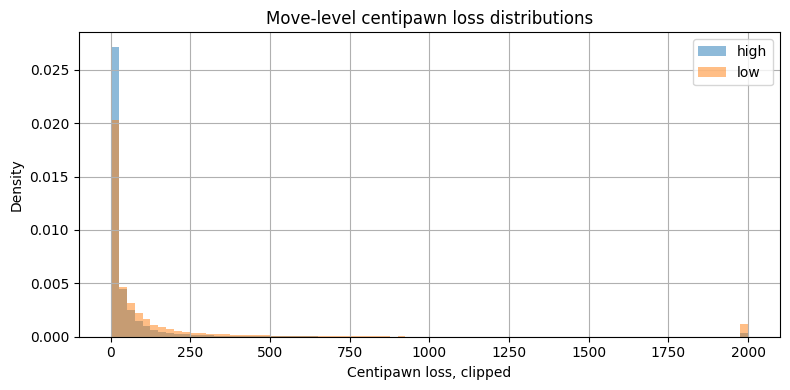

In [17]:
df_moves_with_label = df_moves_eval.merge(
  df_bvt[
    [
      "game_id",
      "rating_class",
      "rating_class_name",
      "white_elo",
      "black_elo",
      "avg_elo",
    ]
  ],
  on="game_id",
  how="left",
)

fig, ax = plt.subplots(figsize=(8, 4))

for class_name, group in df_moves_with_label.groupby("rating_class_name"):
  group["cp_loss_clipped"].hist(
    bins=80,
    alpha=0.5,
    density=True,
    ax=ax,
    label=class_name,
  )

ax.set_xlabel("Centipawn loss, clipped")
ax.set_ylabel("Density")
ax.set_title("Move-level centipawn loss distributions")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
def make_game_level_stockfish_features(df_moves_eval):
  """Aggregate move-level Stockfish data into one feature row per game."""

  df = df_moves_eval.copy()

  # Overall game summaries.
  overall = df.groupby("game_id").agg(
    n_eval_plies=("ply", "count"),

    cp_loss_mean=("cp_loss_clipped", "mean"),
    cp_loss_std=("cp_loss_clipped", "std"),
    cp_loss_median=("cp_loss_clipped", "median"),
    cp_loss_p75=("cp_loss_clipped", lambda x: np.percentile(x, 75)),
    cp_loss_p90=("cp_loss_clipped", lambda x: np.percentile(x, 90)),
    cp_loss_max=("cp_loss_clipped", "max"),

    eval_before_mean=("eval_before_cp", "mean"),
    eval_before_std=("eval_before_cp", "std"),
    eval_after_mean=("eval_after_cp", "mean"),
    eval_after_std=("eval_after_cp", "std"),

    inaccuracy_rate=("is_inaccuracy", "mean"),
    mistake_rate=("is_mistake", "mean"),
    blunder_rate=("is_blunder", "mean"),

    capture_rate=("is_capture", "mean"),
    check_rate=("is_check", "mean"),
    castling_rate=("is_castling", "mean"),
    promotion_rate=("is_promotion", "mean"),
  )

  # Phase-specific centipawn loss summaries.
  phase_mean = df.pivot_table(
    index="game_id",
    columns="phase",
    values="cp_loss_clipped",
    aggfunc="mean",
  )

  phase_mean.columns = [
    f"cp_loss_mean_{col}" for col in phase_mean.columns
  ]

  phase_blunder = df.pivot_table(
    index="game_id",
    columns="phase",
    values="is_blunder",
    aggfunc="mean",
  )

  phase_blunder.columns = [
    f"blunder_rate_{col}" for col in phase_blunder.columns
  ]

  # Side-specific summaries.
  side_loss = df.pivot_table(
    index="game_id",
    columns="mover",
    values="cp_loss_clipped",
    aggfunc="mean",
  )

  side_loss.columns = [
    f"cp_loss_mean_{col}" for col in side_loss.columns
  ]

  side_blunder = df.pivot_table(
    index="game_id",
    columns="mover",
    values="is_blunder",
    aggfunc="mean",
  )

  side_blunder.columns = [
    f"blunder_rate_{col}" for col in side_blunder.columns
  ]

  # Piece-specific average losses.
  piece_loss = df.pivot_table(
    index="game_id",
    columns="piece",
    values="cp_loss_clipped",
    aggfunc="mean",
  )

  piece_loss.columns = [
    f"cp_loss_mean_piece_{col}" for col in piece_loss.columns
  ]

  features = pd.concat(
    [
      overall,
      phase_mean,
      phase_blunder,
      side_loss,
      side_blunder,
      piece_loss,
    ],
    axis=1,
  )

  features = features.replace([np.inf, -np.inf], np.nan)
  features = features.fillna(0)

  return features.reset_index()

In [19]:
df_sf_features = make_game_level_stockfish_features(df_moves_eval)

print(df_sf_features.shape)
df_sf_features.head()

(1000, 35)


,game_id,n_eval_plies,cp_loss_mean,cp_loss_std,cp_loss_median,cp_loss_p75,cp_loss_p90,cp_loss_max,eval_before_mean,eval_before_std,...,cp_loss_mean_black,cp_loss_mean_white,blunder_rate_black,blunder_rate_white,cp_loss_mean_piece_b,cp_loss_mean_piece_k,cp_loss_mean_piece_n,cp_loss_mean_piece_p,cp_loss_mean_piece_q,cp_loss_mean_piece_r
0,0,75,67.400000,107.879437,26.0,86.5,174.2,618,38.600000,326.907376,...,75.270270,59.736842,0.054054,0.026316,61.916667,29.700000,90.666667,90.900000,42.000000,37.357143
1,1,51,71.960784,105.458610,10.0,117.0,210.0,531,34.941176,181.631981,...,74.280000,69.730769,0.000000,0.038462,16.125000,103.500000,42.833333,70.500000,155.571429,89.500000
2,2,47,36.127660,120.580231,3.0,9.0,64.8,746,23.021277,139.713914,...,42.956522,29.583333,0.043478,0.041667,61.200000,2.500000,2.625000,2.818182,132.857143,11.000000
3,3,67,64.522388,84.604491,35.0,87.5,175.8,351,47.552239,24625.285763,...,80.333333,49.176471,0.000000,0.029412,50.545455,103.555556,43.428571,34.176471,84.782609,0.000000
4,4,23,317.173913,671.400277,42.0,169.0,1663.0,2000,8683.521739,28816.332976,...,438.000000,206.416667,0.272727,0.083333,409.833333,0.000000,40.500000,359.857143,518.500000,0.000000


In [20]:
df_model = df_bvt[
  [
    "game_id",
    "rating_class",
    "rating_class_name",
    "num_plies",
    "result",
    "eco",
    "time_control",
  ]
].merge(
  df_sf_features,
  on="game_id",
  how="inner",
)

print(df_model.shape)
df_model.head()

(1000, 41)


,game_id,rating_class,rating_class_name,num_plies,result,eco,time_control,n_eval_plies,cp_loss_mean,cp_loss_std,...,cp_loss_mean_black,cp_loss_mean_white,blunder_rate_black,blunder_rate_white,cp_loss_mean_piece_b,cp_loss_mean_piece_k,cp_loss_mean_piece_n,cp_loss_mean_piece_p,cp_loss_mean_piece_q,cp_loss_mean_piece_r
0,0,0,low,75,1-0,A04,300+0,75,67.400000,107.879437,...,75.270270,59.736842,0.054054,0.026316,61.916667,29.700000,90.666667,90.900000,42.000000,37.357143
1,1,0,low,51,1-0,C20,300+0,51,71.960784,105.458610,...,74.280000,69.730769,0.000000,0.038462,16.125000,103.500000,42.833333,70.500000,155.571429,89.500000
2,2,1,high,47,1-0,E53,180+0,47,36.127660,120.580231,...,42.956522,29.583333,0.043478,0.041667,61.200000,2.500000,2.625000,2.818182,132.857143,11.000000
3,3,0,low,67,1-0,C00,300+0,67,64.522388,84.604491,...,80.333333,49.176471,0.000000,0.029412,50.545455,103.555556,43.428571,34.176471,84.782609,0.000000
4,4,0,low,23,1-0,C57,180+0,23,317.173913,671.400277,...,438.000000,206.416667,0.272727,0.083333,409.833333,0.000000,40.500000,359.857143,518.500000,0.000000


In [21]:
# Numeric features from Stockfish plus basic non-rating metadata.
numeric_cols = [
  col for col in df_model.columns
  if col not in [
    "game_id",
    "rating_class",
    "rating_class_name",
    "result",
    "eco",
    "time_control",
  ]
]

X_num = df_model[numeric_cols].copy()

# Optional categorical one-hot features.
# These are not move-token one-hot features yet.
# They encode metadata such as result, ECO code, and time control.
cat_cols = [
  "result",
  "eco",
  "time_control",
]

X_cat = pd.get_dummies(
  df_model[cat_cols].astype("string"),
  columns=cat_cols,
  dummy_na=True,
)

X_cat.columns = (
  X_cat.columns
  .astype(str)
  .str.replace("[", "(", regex=False)
  .str.replace("]", ")", regex=False)
  .str.replace("<", "lt", regex=False)
  .str.replace(">", "gt", regex=False)
)

X = pd.concat([X_num, X_cat], axis=1)
y = df_model["rating_class"].astype(int)

print("Feature matrix:", X.shape)
print("Target distribution:")
display(y.value_counts().to_frame("count"))

Feature matrix: (1000, 262)
Target distribution:


,count
rating_class,
0,500
1,500


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.25,
  random_state=RANDOM_STATE,
  stratify=y,
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)

display(y_train.value_counts().to_frame("train_count"))
display(y_test.value_counts().to_frame("test_count"))

Train: (750, 262)
Test:  (250, 262)


,train_count
rating_class,
0,375
1,375


,test_count
rating_class,
0,125
1,125


In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import (
  accuracy_score,
  balanced_accuracy_score,
  roc_auc_score,
  classification_report
)

bdt = XGBClassifier(
  n_estimators=500,
  max_depth=3,
  learning_rate=0.03,
  subsample=0.8,
  colsample_bytree=0.8,
  min_child_weight=3,
  reg_lambda=2.0,
  objective="binary:logistic",
  eval_metric="logloss",
  random_state=RANDOM_STATE,
  n_jobs=-1,
)

bdt.fit(X_train, y_train)

y_pred = bdt.predict(X_test)
y_proba = bdt.predict_proba(X_test)[:, 1]

print("Accuracy:          ", accuracy_score(y_test, y_pred))
print("Balanced accuracy: ", balanced_accuracy_score(y_test, y_pred))
print("ROC AUC:           ", roc_auc_score(y_test, y_proba))

print()
print(classification_report(
  y_test,
  y_pred,
  target_names=["low", "high"],
))

Accuracy:           0.944
Balanced accuracy:  0.944
ROC AUC:            0.987584

              precision    recall  f1-score   support

         low       0.92      0.97      0.95       125
        high       0.97      0.92      0.94       125

    accuracy                           0.94       250
   macro avg       0.95      0.94      0.94       250
weighted avg       0.95      0.94      0.94       250

